In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
%matplotlib inline

In [3]:
train = pd.read_csv('../data/raw/train.csv', low_memory=False)
store = pd.read_csv('../data/raw/store.csv')

print("Train shape:", train.shape)
print("Store shape:", store.shape)

Train shape: (1017209, 9)
Store shape: (1115, 10)


In [4]:
df = train.merge(store, on='Store', how='left')
print("Merged shape:", df.shape)
df.head()

Merged shape: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,31-07-2015,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,31-07-2015,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,31-07-2015,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,31-07-2015,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,31-07-2015,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Promo2SinceYear              508031
Promo2SinceWeek              508031
PromoInterval                508031
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
CompetitionDistance            2642
dtype: int64


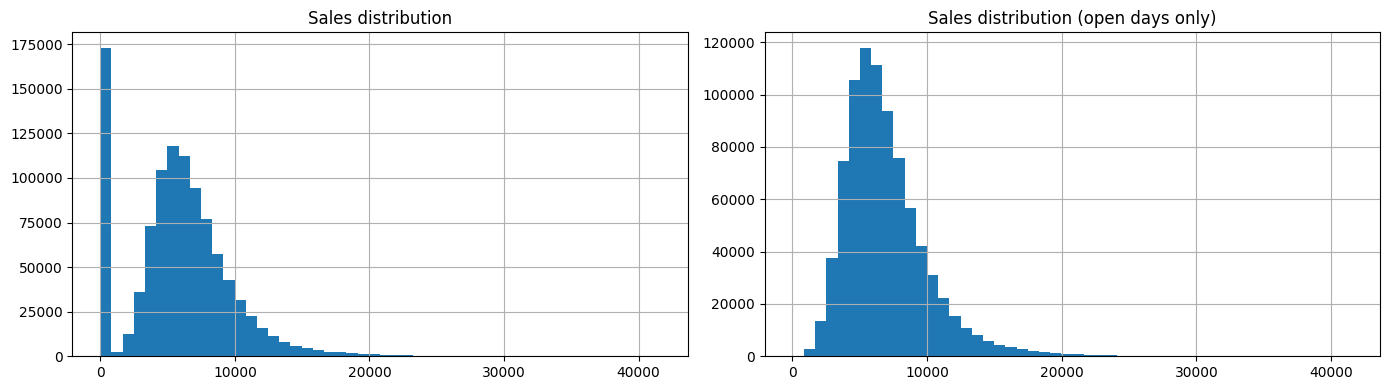

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['Sales'].hist(bins=50, ax=axes[0])
axes[0].set_title('Sales distribution')

df[df['Sales'] > 0]['Sales'].hist(bins=50, ax=axes[1])
axes[1].set_title('Sales distribution (open days only)')

plt.tight_layout()
plt.show()

C:\Users\rushi\AppData\Local\Temp\ipykernel_25308\3957448304.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


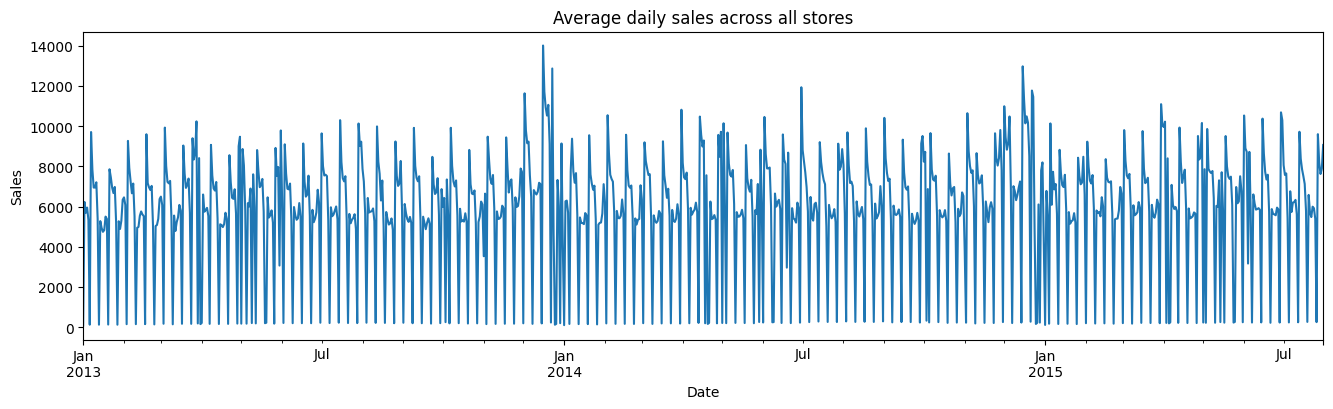

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
daily_sales = df.groupby('Date')['Sales'].mean()

plt.figure(figsize=(16, 4))
daily_sales.plot()
plt.title('Average daily sales across all stores')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [9]:
print(df.groupby('Promo')['Sales'].mean())

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64


In [10]:
print(df.groupby('StoreType')['Sales'].mean())

StoreType
a     5738.179710
b    10058.837334
c     5723.629246
d     5641.819243
Name: Sales, dtype: float64


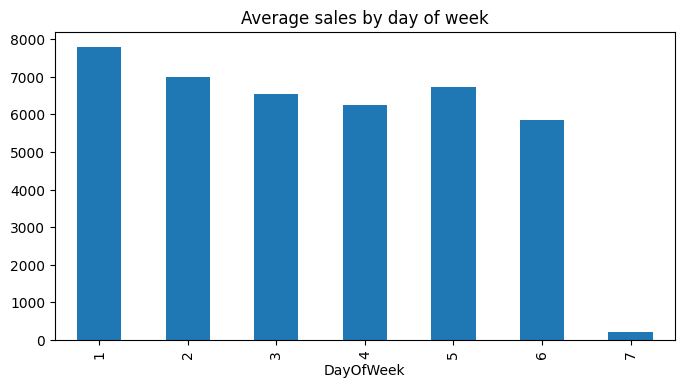

In [11]:
df.groupby('DayOfWeek')['Sales'].mean().plot(kind='bar', figsize=(8, 4))
plt.title('Average sales by day of week')
plt.show()


In [12]:
# How many closed days?
closed = df[df['Open'] == 0]
open_days = df[df['Open'] == 1]
print(f"Closed days: {len(closed):,} ({len(closed)/len(df)*100:.1f}%)")
print(f"Open days: {len(open_days):,} ({len(open_days)/len(df)*100:.1f}%)")

# Sales on closed days — should be zero
print("\nSales stats on closed days:")
print(closed['Sales'].describe())

Closed days: 172,817 (17.0%)
Open days: 844,392 (83.0%)

Sales stats on closed days:
count    172817.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: Sales, dtype: float64


In [13]:
# StateHoliday values
print("StateHoliday values:")
print(df['StateHoliday'].value_counts())

# Sales by holiday type
print("\nAverage sales by StateHoliday:")
print(df[df['Open']==1].groupby('StateHoliday')['Sales'].mean())

# School holidays
print("\nAverage sales by SchoolHoliday:")
print(df[df['Open']==1].groupby('SchoolHoliday')['Sales'].mean())

StateHoliday values:
StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

Average sales by StateHoliday:
StateHoliday
0    6953.515034
a    8487.471182
b    9887.889655
c    9743.746479
Name: Sales, dtype: float64

Average sales by SchoolHoliday:
SchoolHoliday
0    6896.782411
1    7200.181650
Name: Sales, dtype: float64


In [14]:
promo_effect = df[df['Open']==1].groupby('Promo')['Sales'].agg(['mean', 'median', 'count'])
print("Promo effect on sales:")
print(promo_effect)

# Promo lift percentage
no_promo = df[(df['Open']==1) & (df['Promo']==0)]['Sales'].mean()
with_promo = df[(df['Open']==1) & (df['Promo']==1)]['Sales'].mean()
print(f"\nPromo lift: {((with_promo - no_promo) / no_promo * 100):.1f}%")

Promo effect on sales:
              mean  median   count
Promo                             
0      5929.407603  5459.0  467496
1      8228.281239  7649.0  376896

Promo lift: 38.8%


Top 5 highest avg sales stores:
               mean          std  count        cv
Store                                            
817    21757.483418  4674.803920    784  0.214860
262    20718.515924  4668.877584    942  0.225348
1114   20666.562500  3452.938601    784  0.167079
251    19123.068036  3547.641612    779  0.185516
842    18574.795820  3788.985548    622  0.203985

Top 5 most volatile stores:
              mean          std  count        cv
Store                                           
198    2900.604859  1597.761904    782  0.550837
897    3492.944730  1810.461801    778  0.518320
607    3901.910486  1879.566980    782  0.481704
126    6507.753530  3049.536739    779  0.468601
575    5367.566613  2472.728592    623  0.460680


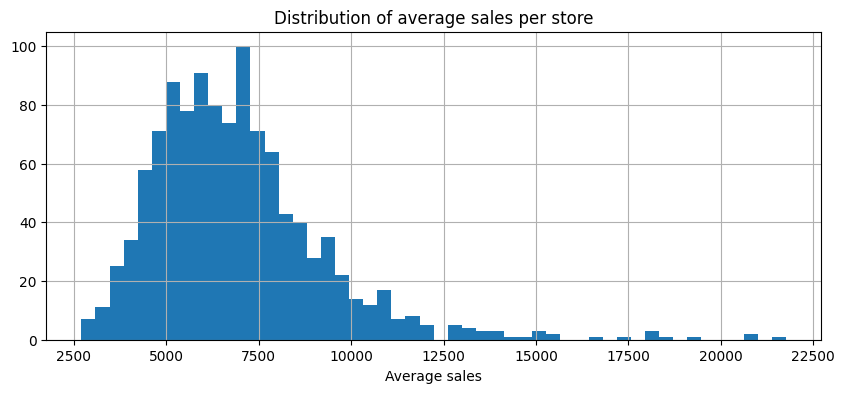

In [15]:
# Sales variance across stores
store_stats = df[df['Open']==1].groupby('Store')['Sales'].agg(['mean', 'std', 'count'])
store_stats['cv'] = store_stats['std'] / store_stats['mean']  # coefficient of variation

print("Top 5 highest avg sales stores:")
print(store_stats.nlargest(5, 'mean'))

print("\nTop 5 most volatile stores:")
print(store_stats.nlargest(5, 'cv'))

# Plot distribution of per-store average sales
store_stats['mean'].hist(bins=50, figsize=(10, 4))
plt.title('Distribution of average sales per store')
plt.xlabel('Average sales')
plt.show()

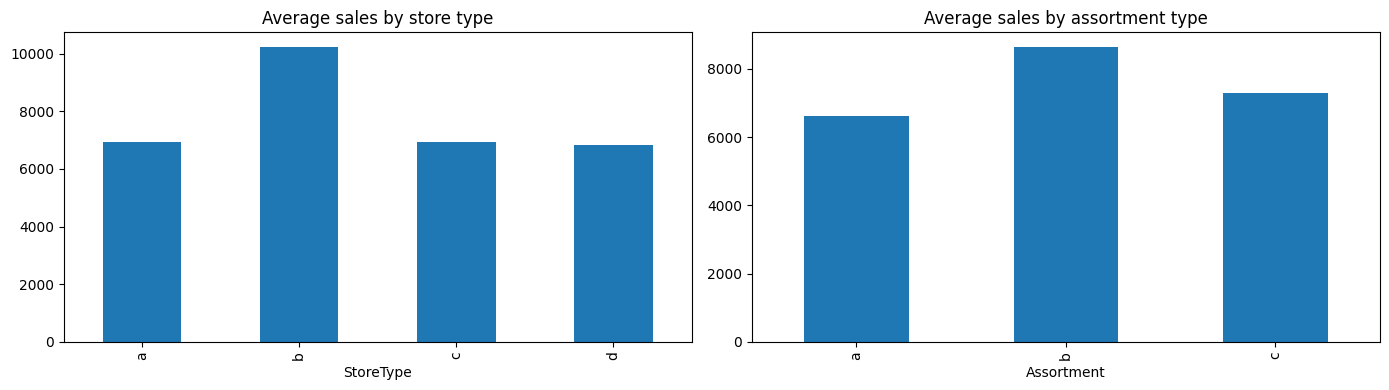

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Sales by store type
df[df['Open']==1].groupby('StoreType')['Sales'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Average sales by store type')

# Sales by assortment
df[df['Open']==1].groupby('Assortment')['Sales'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Average sales by assortment type')

plt.tight_layout()
plt.show()

## Key EDA findings

1. 172,817 rows have Sales=0 (closed days) — filter these before modelling
2. Sales are right-skewed — consider log transformation of target
3. Strong weekly seasonality — day of week is a critical feature
4. Day 7 (Sunday) near-zero sales — most stores closed
5. Holiday spikes visible in Jan 2014 and Dec 2014 — holiday features matter
6. CompetitionDistance has nulls — fill with large value (no competitor)
7. Mixed types in column 7 (StateHoliday) — needs cleaning